In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import shapiro, spearmanr, mannwhitneyu, kruskal, kendalltau, median_test

In [2]:
#данные индекса человеческого прогресса
data_hpi = {
    'Country': ['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 
               'Bulgaria', 'Cyprus', 'Estonia', 'Finland', 'France', 
               'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 
               'Ireland', 'Israel', 'Italy', 'Kazakhstan', 'Liechtenstein', 
               'Lithuania', 'Malta', 'Monaco', 'Montenegro', 'Netherlands', 
               'Poland', 'Portugal', 'Romania', 'Serbia', 'Spain', 
               'Sweden', 'Tajikistan', 'Turkiye', 'Ukraine', 'United Kingdom', 'Uzbekistan'],
    'HPI': [77.27, 88.62, 77.08, 92.5, 74.32, 
                              78.6, 90.1, 89.72, 95.12, 90.22, 
                              80.55, 96.54, 89.44, 86.04, 97.47, 
                              96.08, 91.88, 89.76, 79.32, 93.84, 
                              88.37, 90.78, 94.16, 84.23, 95.7, 
                              88.42, 87, 83.05, 79.4, 90.37, 
                              97.28, 63.4, 86.59, 72.15, 93.82, 70.94]
}

df_hpi = pd.DataFrame(data_hpi)

#даные туристических прибытий
data_tourism = {
    'Country': ['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 
                'Bulgaria', 'Cyprus', 'Estonia', 'Finland', 'France', 
                'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 
                'Ireland', 'Israel', 'Italy', 'Kazakhstan', 'Liechtenstein', 
                'Lithuania', 'Malta', 'Monaco', 'Montenegro', 'Netherlands', 
                'Poland', 'Portugal', 'Romania', 'Serbia', 'Spain', 
                'Sweden', 'Tajikistan', 'Turkiye', 'Ukraine', 'United Kingdom', 
                'Uzbekistan'],
    'Value': [11.50, 4.20, 2.20, 31.90, 1.90, 
              8.60, 4.00, 2.70, 2.90, 102.00, 
              5.10, 37.50, 36.00, 13.20, 2.30, 
              6.60, 0.96, 57.70, 10.40, 0.12, 
              2.40, 3.60, 0.35, 2.40, 21.30, 
              19.70, 29.00, 2.40, 2.40, 93.80, 
              8.70, 1.40, 60.60, 2.50, 41.80, 
              10.10]
}

df_tourism = pd.DataFrame(data_tourism)

data_attractions = {
    'Country': ['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 
               'Bulgaria', 'Cyprus', 'Estonia', 'Finland', 'France', 
               'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 
               'Ireland', 'Israel', 'Italy', 'Kazakhstan', 'Liechtenstein', 
               'Lithuania', 'Malta', 'Monaco', 'Montenegro', 'Netherlands', 
               'Poland', 'Portugal', 'Romania', 'Serbia', 'Spain', 
               'Sweden', 'Tajikistan', 'Turkiye', 'Ukraine', 'United Kingdom', 
               'Uzbekistan'],
    'Attractions': [305, 428, 305, 3949, 174, 1332, 1124, 700, 1759, 22219,
                   359, 14239, 4913, 870, 270, 794, 612, 39213, 349, 34,
                   511, 910, 42, 663, 3767, 3324, 6170, 1659, 231, 13636,
                   2367, 67, 6219, 1874, 22003, 211]
}

df_attr = pd.DataFrame(data_attractions)

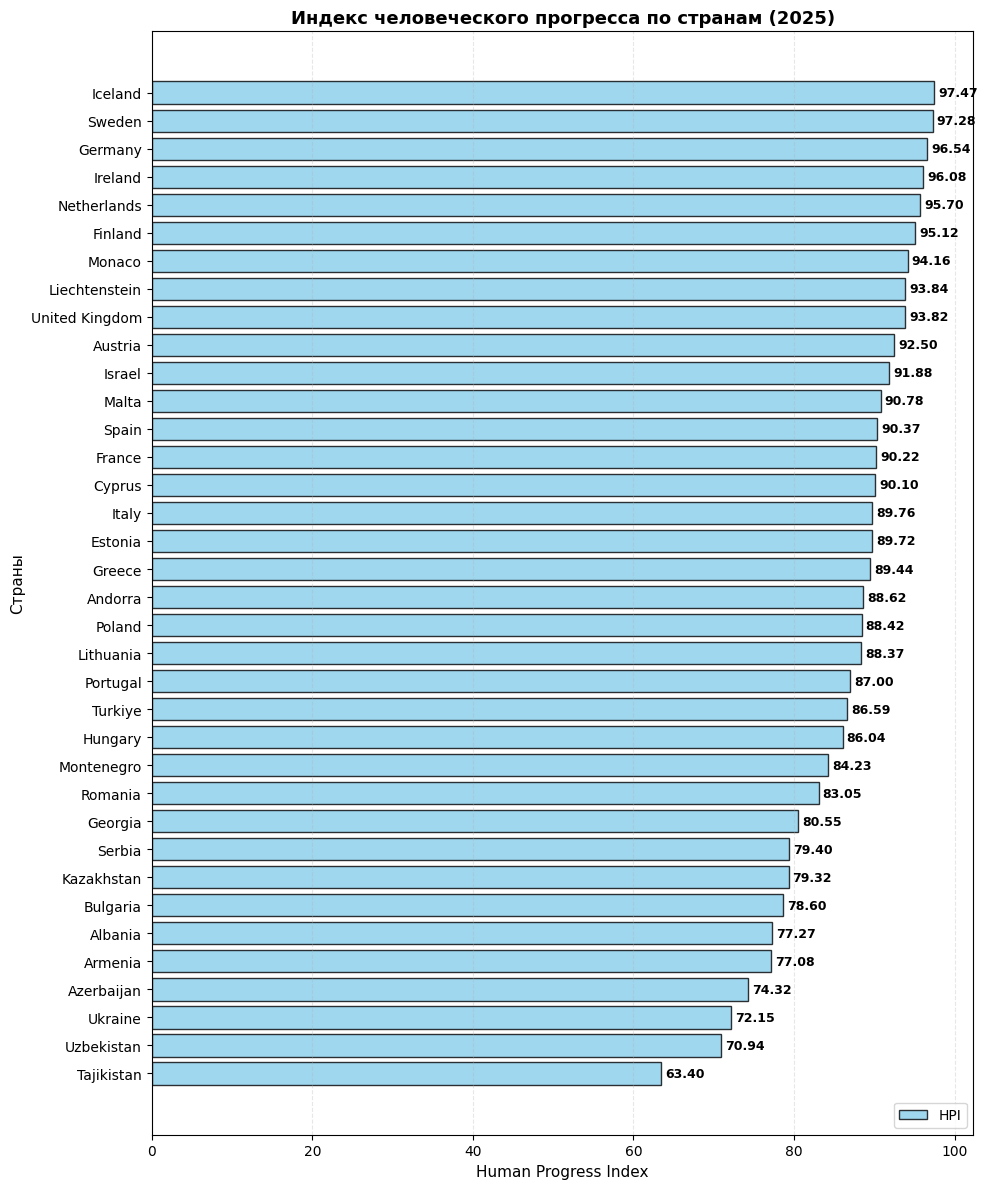

In [3]:
#гистограмма индекса человеческого прогресса
df_sorted = df_hpi.sort_values('HPI')

# Построение горизонтальной диаграммы
plt.figure(figsize=(10, 12))
plt.barh(df_sorted['Country'], df_sorted['HPI'],
         color='skyblue', edgecolor='black', alpha=0.8, label='HPI')

# Подписи осей, заголовок, легенда
plt.xlabel('Human Progress Index', fontsize=11)
plt.ylabel('Страны', fontsize=11)
plt.title('Индекс человеческого прогресса по странам (2025)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Добавление значений напротив каждой страны 
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    plt.text(row['HPI'] + 0.5, i, f'{row["HPI"]:.2f}', 
             va='center', fontsize=9, fontweight='bold')

# Отображение
plt.tight_layout()
plt.show()

In [4]:
#критерий Шапиро-Уилка 
# Для туристических прибытий
shapiro(df_tourism['Value'])

ShapiroResult(statistic=np.float64(0.6940783567109574), pvalue=np.float64(2.2865729513731552e-07))

In [5]:
# Для HPI
shapiro(df_hpi['HPI'])

ShapiroResult(statistic=np.float64(0.9248735442786816), pvalue=np.float64(0.017547104395363743))

In [6]:
#критерий спирмана
spearmanr(df_tourism['Value'], df_hpi['HPI'], axis=0, nan_policy='propagate', alternative='two-sided')

SignificanceResult(statistic=np.float64(0.1586606896857724), pvalue=np.float64(0.3553610510472296))

In [7]:
df_merged = pd.merge(df_hpi, df_tourism, on='Country', how='inner')

# Деление на группы по медиане HPI
median_hpi = np.median(df_merged['HPI'])
group_high = df_merged.loc[df_merged['HPI'] >= median_hpi, 'Value']
group_low = df_merged.loc[df_merged['HPI'] < median_hpi, 'Value']


In [8]:
mannwhitneyu(group_high, group_low, alternative='two-sided', use_continuity=True)

MannwhitneyuResult(statistic=np.float64(193.0), pvalue=np.float64(0.33424494638494673))

In [9]:
q1, q2 = np.percentile(df_merged['HPI'], [33.33, 66.67])

group1 = df_merged.loc[df_merged['HPI'] < q1, 'Value'] #Низкий HPI
group2 = df_merged.loc[(df_merged['HPI'] >= q1) & (df_merged['HPI'] < q2), 'Value'] #Средний HPI
group3 = df_merged.loc[df_merged['HPI'] >= q2, 'Value'] #Высокий HPI
print(q1, q2)



85.434555 90.50714500000001


In [10]:
kruskal(group1, group2, group3)

KruskalResult(statistic=np.float64(7.864100085910646), pvalue=np.float64(0.019603443430335193))

In [11]:
kendalltau(df_merged['Value'], df_merged['HPI'], alternative='two-sided')

SignificanceResult(statistic=np.float64(0.13078299623495443), pvalue=np.float64(0.2636471438656839))

In [12]:
median_test(group1, group2, group3, ties='below', correction=True)


MedianTestResult(statistic=np.float64(2.6666666666666665), pvalue=np.float64(0.26359713811572677), median=np.float64(5.85), table=array([[4, 8, 6],
       [8, 4, 6]]))

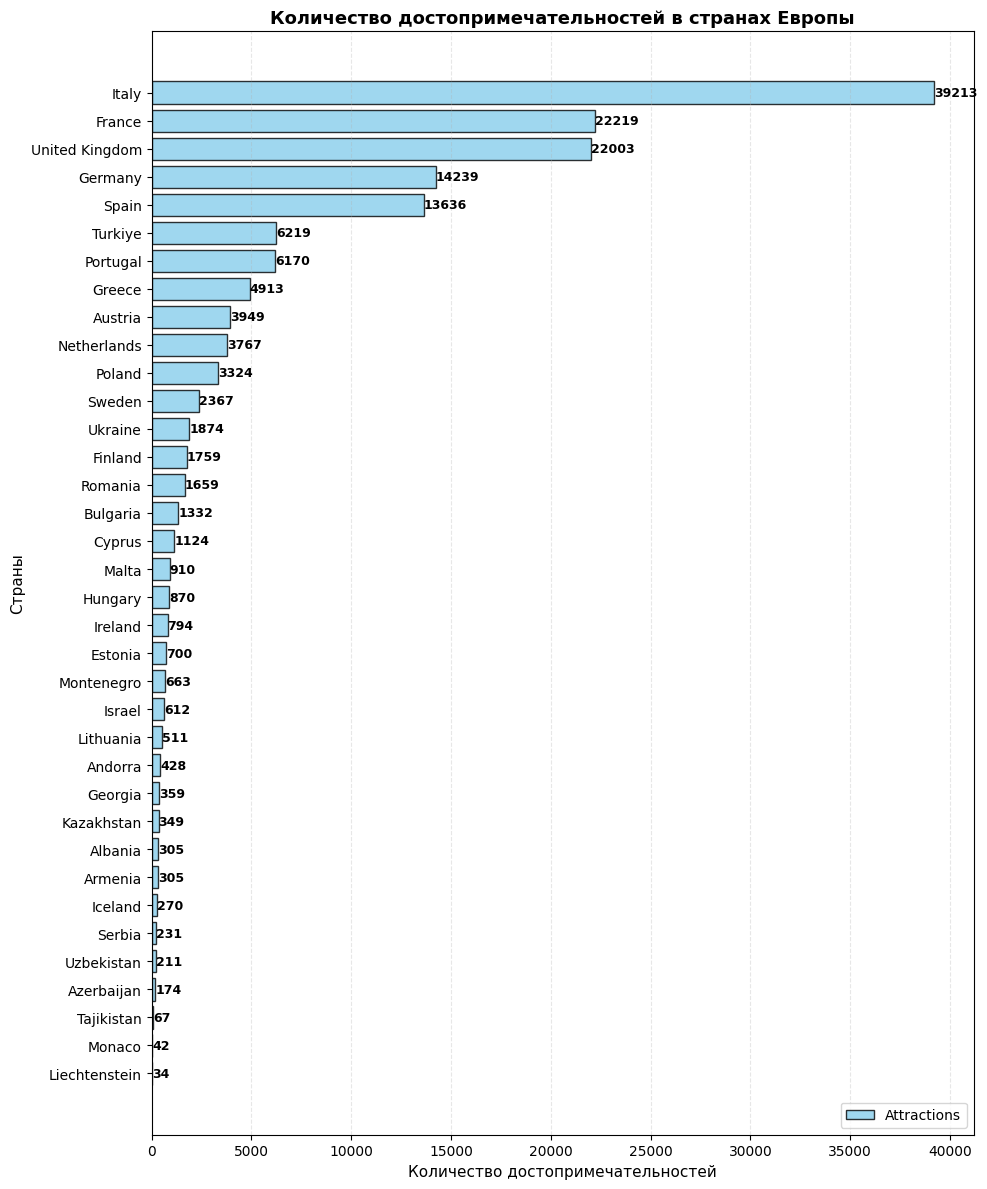

In [13]:
#гистограмма индекса человеческого прогресса
df_sorted1 = df_attr.sort_values('Attractions')

# Построение горизонтальной диаграммы
plt.figure(figsize=(10, 12))
plt.barh(df_sorted1['Country'], df_sorted1['Attractions'],
         color='skyblue', edgecolor='black', alpha=0.8, label='Attractions')

# Подписи осей, заголовок, легенда
plt.xlabel('Количество достопримечательностей', fontsize=11)
plt.ylabel('Страны', fontsize=11)
plt.title('Количество достопримечательностей в странах Европы', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Добавление значений напротив каждой страны 
for i, (idx, row) in enumerate(df_sorted1.iterrows()):
    plt.text(row['Attractions'] + 0.5, i, f'{row["Attractions"]}', 
             va='center', fontsize=9, fontweight='bold')

# Отображение
plt.tight_layout()
plt.show()

In [15]:
df_merged2 = pd.merge(df_merged, df_attr, on='Country', how='inner')

In [16]:
shapiro(df_merged2['Attractions'])

ShapiroResult(statistic=np.float64(0.5663182689857806), pvalue=np.float64(3.89038583707406e-09))

In [18]:
spearmanr(df_merged2['Value'], df_merged2['Attractions'])

SignificanceResult(statistic=np.float64(0.8080367124334515), pvalue=np.float64(2.5503784715331127e-09))

In [19]:
median_hpi2 = np.median(df_merged2['HPI'])
group_high2 = df_merged2.loc[df_merged2['HPI'] >= median_hpi, 'Attractions']
group_low2 = df_merged2.loc[df_merged2['HPI'] < median_hpi, 'Attractions']
mannwhitneyu(group_high2, group_low2, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(227.0), pvalue=np.float64(0.04126862024306162))

In [21]:
q1_2, q2_2 = np.percentile(df_merged['HPI'], [33.33, 66.67])
g1_2 = df_merged2.loc[df_merged['HPI'] < q1_2, 'Attractions']
g2_2 = df_merged2.loc[(df_merged['HPI'] >= q1_2) & (df_merged2['HPI'] < q2_2), 'Attractions']
g3_2 = df_merged2.loc[df_merged['HPI'] >= q2_2, 'Attractions']
kruskal(g1_2, g2_2, g3_2)

KruskalResult(statistic=np.float64(9.682927875745456), pvalue=np.float64(0.007895487084432032))